# Лабораторна робота №3. Дослідження біполярних транзисторів

**Мета роботи:** вивчення принципу дії, основних властивостей та характеристик біполярного транзистора, ознайомлення з його основними параметрами і методикою їх вимірювання.

У цьому зошиті лабораторна робота виконується не в TINA, а шляхом SPICE-моделювання (PySpice + ngspice) — за ідеєю, використаною раніше в `Електронні_прилади.ipynb` для зняття ВАХ транзистора (комірки з `Ibase`/`Vcollector`, розгортка по постійному струму, побудова сімейств кривих у циклі).

**У цій першій версії використовується generic (типова) SPICE-модель малопотужного NPN транзистора — 2N3904** (`2n3904.lib`, вже є в теці репозиторію), а не точна модель транзистора, призначеного вашій бригаді (2N1566, 2N1613, 2N1711, 2N1893, 2N2102, 2N2218). Готових SPICE-моделей саме цих (застарілих) приладів немає, тому методику одразу відпрацьовуємо на сучасному, добре задокументованому аналозі. Якщо буде знайдено `.model`/`.lib` для потрібного транзистора — досить замінити `MODEL_FILE`/`MODEL_NAME` в комірці нижче, і всі розрахунки перерахуються автоматично.

## Короткі теоретичні відомості

Кожна схема включення транзистора (СЕ — спільний емітер, СБ — спільна база) характеризується сімействами вхідних і вихідних ВАХ. Малосигнальні h-параметри чотириполюсника визначаються системою

$$U_1 = h_{11} I_1 + h_{12} U_2$$
$$I_2 = h_{21} I_1 + h_{22} U_2$$

де для схеми СЕ: $U_1=U_{БЕ},\ I_1=I_Б,\ U_2=U_{КЕ},\ I_2=I_К$; для схеми СБ: $U_1=U_{ЕБ},\ I_1=I_Е,\ U_2=U_{КБ},\ I_2=I_К$.

Приблизні значення h-параметрів знаходять графоаналітичним методом — за кінцевими приростами струмів і напруг поблизу робочої точки на сімействах статичних характеристик (метод "курсорів" a, b):

$$h_{11}=\frac{\Delta U_1}{\Delta I_1}\Big|_{U_2=const}\qquad h_{12}=\frac{\Delta U_1}{\Delta U_2}\Big|_{I_1=const}\qquad h_{21}=\frac{\Delta I_2}{\Delta I_1}\Big|_{U_2=const}\qquad h_{22}=\frac{\Delta I_2}{\Delta U_2}\Big|_{I_1=const}$$

Зв'язок h-параметрів з фізичними параметрами транзистора (rе, rб, rк — опори емітера, бази, колектора; µек — коефіцієнт зворотного зв'язку; α, β — коефіцієнти передачі струму):

$$r_е = h_{11б} - (1-h_{21б})\frac{h_{12б}}{h_{22б}} = \frac{h_{12е}}{h_{22е}} \qquad
 r_б = \frac{h_{12б}}{h_{22б}} = h_{11е} - (1+h_{21е})\frac{h_{12е}}{h_{22е}}$$

$$r_к = \frac{1}{h_{22б}} = \frac{1+h_{21е}}{h_{22е}} \qquad
 \mu_{ек} = h_{12б} = \frac{h_{11е} h_{22е}}{1+h_{21е}} - h_{12е}$$

$$\alpha = h_{21б} = \frac{h_{21е}}{1+h_{21е}} \qquad
 \beta = \frac{h_{21б}}{1-h_{21б}} = h_{21е}$$

**Розподіл транзисторів по бригадах (для довідкових h-параметрів з документації):**

| Бригада | Транзистор |
|---|---|
| 1 | 2N1566 |
| 2 | 2N1613 |
| 3 | 2N1711 |
| 4 | 2N1893 |
| 5 | 2N2102 |
| 6 | 2N2218 |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *

%matplotlib inline

/home/bp/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Модель транзистора та схеми для зняття ВАХ

Побудова схем повторює п. 3.3 методички:

* **СЕ, вхідні характеристики** (рис. 3.7) — джерело струму бази $I_Б$ (IS1) розгортається, джерело напруги колектор-емітер $U_{КЕ}$ (VS1) — параметр сімейства.
* **СЕ, вихідні характеристики** (рис. 3.11) — розгортається $U_{КЕ}$ (VS1), параметр сімейства — $I_Б$ (IS1).
* **СБ, вхідні характеристики** (рис. 3.13) — розгортається $I_Е$ (IS1), параметр — $U_{КБ}$ (VS1); база — спільний (заземлений) електрод.
* **СБ, вихідні характеристики** (рис. 3.15) — розгортається $U_{КБ}$ (VS1), параметр — $I_Е$ (IS1).

**Важливо (типова пастка PySpice/ngspice):** якщо задавати струм напряму як `0.001@u_A`, PySpice запише в netlist `"0.001A"`. ngspice трактує літеру, що йде одразу після числа (без множника), як префікс — а самотня `a`/`A` означає **atto** ($10^{-18}$), тому джерело фактично перетворюється на нуль без жодної помилки чи попередження. Тому нижче постійні значення струму/напруги задаються звичайними числами (в базових одиницях СІ, тобто в амперах і вольтах) без символу одиниці виміру.

In [2]:
MODEL_FILE = '2n3904.lib'   # generic (типова) SPICE-модель малопотужного NPN
MODEL_NAME = 'Q2N3904'


def make_ce_circuit():
    """Транзистор у включенні із спільним емітером: I(база), V(колектор-емітер)."""
    circuit = Circuit('CE characterization')
    circuit.include(MODEL_FILE)
    Ib_src = circuit.I('B', circuit.gnd, 'base', 0)        # IS1: джерело струму бази
    Vc_src = circuit.V('C', 'collector', circuit.gnd, 0)   # VS1: джерело напруги колектора
    circuit.BJT(1, 'collector', 'base', circuit.gnd, model=MODEL_NAME)
    return circuit, Ib_src, Vc_src


def make_cb_circuit():
    """Транзистор у включенні із спільною базою: I(емітер), V(колектор-база), база заземлена."""
    circuit = Circuit('CB characterization')
    circuit.include(MODEL_FILE)
    Ie_src = circuit.I('E', 'emitter', circuit.gnd, 0)      # IS1: джерело струму емітера
    Vc_src = circuit.V('C', 'collector', circuit.gnd, 0)    # VS1: джерело напруги колектор-база
    circuit.BJT(1, 'collector', circuit.gnd, 'emitter', model=MODEL_NAME)
    return circuit, Ie_src, Vc_src


def ce_input_characteristics(vce_values, ib_max=2e-3, n_points=1000):
    """Сімейство Iб = f(Uбе) для декількох Uке."""
    circuit, Ib_src, Vc_src = make_ce_circuit()
    curves = {}
    for vce in vce_values:
        Vc_src.dc_value = vce
        simulator = circuit.simulator(temperature=25, nominal_temperature=25)
        analysis = simulator.dc(IB=slice(0, ib_max, ib_max / n_points))
        curves[vce] = (np.array(analysis.sweep), np.array(analysis.base))
    return curves


def ce_output_characteristics(ib_values, vce_max=30, n_points=1000):
    """Сімейство Iк = f(Uке) для декількох Iб."""
    circuit, Ib_src, Vc_src = make_ce_circuit()
    curves = {}
    for ib in ib_values:
        Ib_src.dc_value = ib
        simulator = circuit.simulator(temperature=25, nominal_temperature=25)
        analysis = simulator.dc(VC=slice(0, vce_max, vce_max / n_points))
        curves[ib] = (np.array(analysis.sweep), -np.array(analysis.VC))
    return curves


def cb_input_characteristics(vcb_values, ie_max=100e-3, n_points=1000):
    """Сімейство Iе = f(Uеб) для декількох Uкб."""
    circuit, Ie_src, Vc_src = make_cb_circuit()
    curves = {}
    for vcb in vcb_values:
        Vc_src.dc_value = vcb
        simulator = circuit.simulator(temperature=25, nominal_temperature=25)
        analysis = simulator.dc(IE=slice(0, ie_max, ie_max / n_points))
        curves[vcb] = (np.array(analysis.sweep), -np.array(analysis.emitter))
    return curves


def cb_output_characteristics(ie_values, vcb_min=-2, vcb_max=30, n_points=1000):
    """Сімейство Iк = f(Uкб) для декількох Iе."""
    circuit, Ie_src, Vc_src = make_cb_circuit()
    curves = {}
    for ie in ie_values:
        Ie_src.dc_value = ie
        simulator = circuit.simulator(temperature=25, nominal_temperature=25)
        analysis = simulator.dc(VC=slice(vcb_min, vcb_max, (vcb_max - vcb_min) / n_points))
        curves[ie] = (np.array(analysis.sweep), -np.array(analysis.VC))
    return curves

## 3.3 Проведення дослідження

### 3.3.1-3.3.2 Схема із спільним емітером (СЕ)

Unsupported Ngspice version 42
Using SPARSE 1.3 as Direct Linear Solver
Using SPARSE 1.3 as Direct Linear Solver
Using SPARSE 1.3 as Direct Linear Solver
Using SPARSE 1.3 as Direct Linear Solver


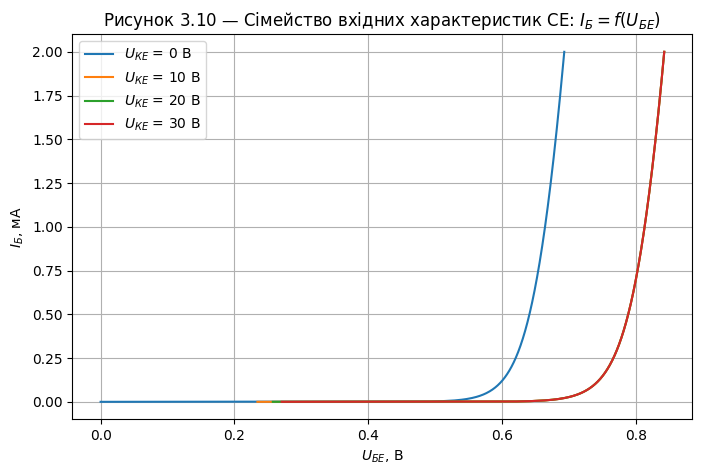

In [3]:
vce_family = [0, 10, 20, 30]     # В — параметр сімейства (як в п.3.2 методички)
ce_in = ce_input_characteristics(vce_family)

plt.figure(figsize=(8, 5))
for vce, (ib, vbe) in ce_in.items():
    plt.plot(vbe, ib * 1e3, label=f'$U_{{КЕ}}$ = {vce} В')
plt.xlabel('$U_{БЕ}$, В')
plt.ylabel('$I_Б$, мА')
plt.title('Рисунок 3.10 — Сімейство вхідних характеристик СЕ: $I_Б=f(U_{БЕ})$')
plt.legend()
plt.grid(True)
plt.show()

Using SPARSE 1.3 as Direct Linear Solver
Using SPARSE 1.3 as Direct Linear Solver
Using SPARSE 1.3 as Direct Linear Solver
Using SPARSE 1.3 as Direct Linear Solver
Using SPARSE 1.3 as Direct Linear Solver
Using SPARSE 1.3 as Direct Linear Solver


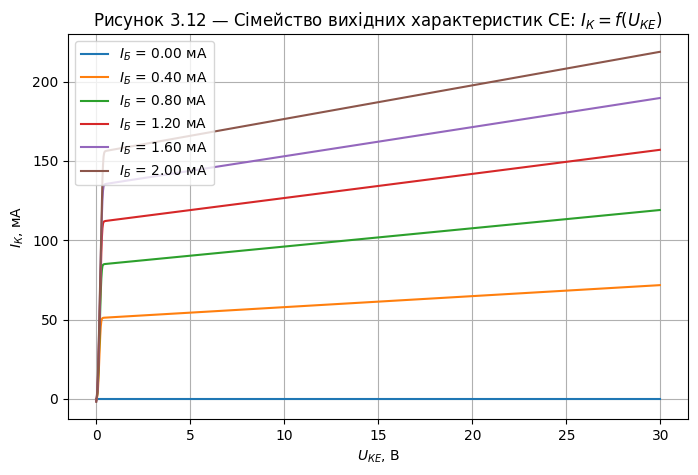

In [4]:
ib_family = np.linspace(0, 2e-3, 6)   # А — параметр сімейства (0..2 мА, 6 значень)
ce_out = ce_output_characteristics(ib_family)

plt.figure(figsize=(8, 5))
for ib, (vce, ic) in ce_out.items():
    plt.plot(vce, ic * 1e3, label=f'$I_Б$ = {ib * 1e3:.2f} мА')
plt.xlabel('$U_{КЕ}$, В')
plt.ylabel('$I_К$, мА')
plt.title('Рисунок 3.12 — Сімейство вихідних характеристик СЕ: $I_К=f(U_{КЕ})$')
plt.legend()
plt.grid(True)
plt.show()

### 3.3.3-3.3.4 Схема із спільною базою (СБ)

Using SPARSE 1.3 as Direct Linear Solver
Using SPARSE 1.3 as Direct Linear Solver
Using SPARSE 1.3 as Direct Linear Solver
Using SPARSE 1.3 as Direct Linear Solver


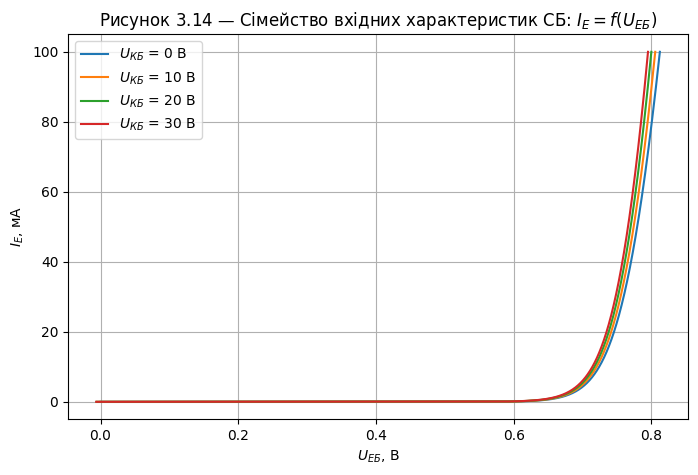

In [5]:
vcb_family = [0, 10, 20, 30]        # В — параметр сімейства
cb_in = cb_input_characteristics(vcb_family)

plt.figure(figsize=(8, 5))
for vcb, (ie, veb) in cb_in.items():
    plt.plot(veb, ie * 1e3, label=f'$U_{{КБ}}$ = {vcb} В')
plt.xlabel('$U_{ЕБ}$, В')
plt.ylabel('$I_Е$, мА')
plt.title('Рисунок 3.14 — Сімейство вхідних характеристик СБ: $I_Е=f(U_{ЕБ})$')
plt.legend()
plt.grid(True)
plt.show()

Using SPARSE 1.3 as Direct Linear Solver
Using SPARSE 1.3 as Direct Linear Solver
Using SPARSE 1.3 as Direct Linear Solver
Using SPARSE 1.3 as Direct Linear Solver
Using SPARSE 1.3 as Direct Linear Solver
Using SPARSE 1.3 as Direct Linear Solver


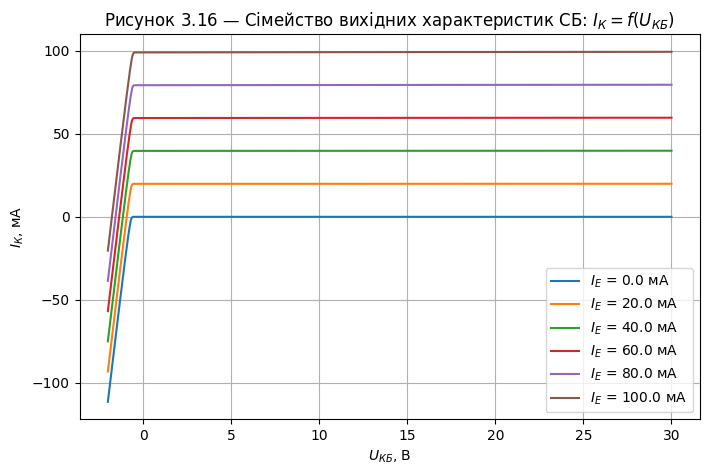

In [6]:
ie_family = np.linspace(0, 100e-3, 6)   # А — параметр сімейства (0..100 мА, 6 значень)
cb_out = cb_output_characteristics(ie_family)

plt.figure(figsize=(8, 5))
for ie, (vcb, ic) in cb_out.items():
    plt.plot(vcb, ic * 1e3, label=f'$I_Е$ = {ie * 1e3:.1f} мА')
plt.xlabel('$U_{КБ}$, В')
plt.ylabel('$I_К$, мА')
plt.title('Рисунок 3.16 — Сімейство вихідних характеристик СБ: $I_К=f(U_{КБ})$')
plt.legend()
plt.grid(True)
plt.show()

## 3.4 Обробка результатів

Замість переміщення курсорів "a"/"b" мишею (як в TINA) значення похідних в робочій точці визначаються чисельно:

* **вздовж однієї кривої** (`local_slope`) — центральна різниця в двох сусідніх точках густої розгортки поблизу заданого $I_Б$ (або $U_{КЕ}$, $I_Е$, $U_{КБ}$);
* **між двома сусідніми кривими сімейства** (`cross_family_slope`) — різниця значень, інтерпольованих в одній і тій самій точці іншої змінної, поділена на крок параметра сімейства.

Це є прямим числовим аналогом графоаналітичного методу з п. 3.4 методички.

In [7]:
def local_slope(x, y, x0):
    """dy/dx поблизу x0 — метод двох курсорів на одній кривій."""
    idx = int(np.argmin(np.abs(np.asarray(x) - x0)))
    i0, i1 = max(idx - 1, 0), min(idx + 1, len(x) - 1)
    slope = (y[i1] - y[i0]) / (x[i1] - x[i0])
    return slope, x[idx], y[idx]


def cross_family_slope(curves, param0, x_at):
    """dy/d(параметр) при фіксованому x_at - курсори на двох НАЙБЛИЖЧИХ до param0 кривих сімейства."""
    params = np.array(sorted(curves.keys()))
    nearest_two = np.sort(np.argsort(np.abs(params - param0))[:2])
    p0, p1 = params[nearest_two[0]], params[nearest_two[1]]
    x0arr, y0arr = curves[p0]
    x1arr, y1arr = curves[p1]
    y0, y1 = np.interp(x_at, x0arr, y0arr), np.interp(x_at, x1arr, y1arr)
    slope = 0.0 if p1 == p0 else (y1 - y0) / (p1 - p0)
    return slope, p0, p1, y0, y1


def physical_from_ce(h11e, h12e, h21e, h22e):
    re = h12e / h22e
    rb = h11e - (1 + h21e) * (h12e / h22e)
    rk = (1 + h21e) / h22e
    muek = h11e * h22e / (1 + h21e) - h12e
    alpha = h21e / (1 + h21e)
    beta = h21e
    return dict(re=re, rb=rb, rk=rk, muek=muek, alpha=alpha, beta=beta)


def physical_from_cb(h11b, h12b, h21b, h22b):
    re = h11b - (1 - h21b) * (h12b / h22b)
    rb = h12b / h22b
    rk = 1 / h22b
    muek = h12b
    alpha = h21b
    beta = h21b / (1 - h21b)
    return dict(re=re, rb=rb, rk=rk, muek=muek, alpha=alpha, beta=beta)

### Робоча точка

Оберіть робочу точку відповідно до вашої ролі в бригаді (перший студент — максимальний $I_Б$/$I_Е$, другий — середній, третій — мінімальний, п. 3.4.1 методички). Нижче — приклад для "середнього" студента бригади.

In [8]:
# --- Робоча точка СЕ ---
Ib0, Vce0 = 1.0e-3, 15   # А, В

vce_key = min(ce_in.keys(), key=lambda v: abs(v - Vce0))
h11e, ib_a, vbe_a = local_slope(*ce_in[vce_key], Ib0)
h21e, ib_lo, ib_hi, ic_lo, ic_hi = cross_family_slope(ce_out, Ib0, Vce0)
h12e, vce_lo, vce_hi, vbe_lo, vbe_hi = cross_family_slope(ce_in, Vce0, Ib0)
ib_key = min(ce_out.keys(), key=lambda i: abs(i - Ib0))
h22e, vce_a, ic_a = local_slope(*ce_out[ib_key], Vce0)

print(f'h11e = {h11e:8.2f} Ом')
print(f'h12e = {h12e:8.5f}')
print(f'h21e = {h21e:8.2f}')
print(f'h22e = {h22e * 1e6:8.3f} мкСм')

h11e =    38.01 Ом
h12e =  0.00000
h21e =    81.13
h22e = 1153.765 мкСм


In [9]:
# --- Робоча точка СБ ---
# Щоб порівняння параметрів СЕ <-> СБ мало сенс, беремо ТУ Ж САМУ фізичну робочу точку
# транзистора: Ie = Ib + Ic, Vcb = Vce - Vbe (KVL контуру Е-Б-К), а не довільні числа.
Ie0 = Ib0 + ic_a
Vcb0 = Vce0 - vbe_a
print(f'Ie0 = {Ie0 * 1e3:.2f} мА,  Vcb0 = {Vcb0:.2f} В  (перерахунок робочої точки СЕ у СБ)')

vcb_key = min(cb_in.keys(), key=lambda v: abs(v - Vcb0))
h11b, ie_a, veb_a = local_slope(*cb_in[vcb_key], Ie0)
h21b, ie_lo, ie_hi, ic_lo_b, ic_hi_b = cross_family_slope(cb_out, Ie0, Vcb0)
h12b, vcb_lo, vcb_hi, veb_lo, veb_hi = cross_family_slope(cb_in, Vcb0, Ie0)
ie_key = min(cb_out.keys(), key=lambda i: abs(i - Ie0))
h22b, vcb_a, ic_a_b = local_slope(*cb_out[ie_key], Vcb0)

print(f'h11b = {h11b:8.3f} Ом')
print(f'h12b = {h12b:8.5f}')
print(f'h21b = {h21b:8.4f}')
print(f'h22b = {h22b * 1e6:8.3f} мкСм')

Ie0 = 102.80 мА,  Vcb0 = 14.19 В  (перерахунок робочої точки СЕ у СБ)
h11b =    0.520 Ом
h12b = -0.00057
h21b =   0.9897
h22b =   12.308 мкСм


### Довідкові h-параметри

Занесіть сюди h-параметри транзистора вашої бригади зі схемотехнічного довідника (для схеми СЕ). Якщо значення невідомі — залиште `None`, відповідний рядок таблиці залишиться порожнім.

In [10]:
# TODO: підставте довідкові h-параметри для СВОГО транзистора (див. таблицю бригад вище)
h11e_ref = None   # Ом
h12e_ref = None
h21e_ref = None
h22e_ref = None   # См

### Таблиця 3.1 — Розраховані та довідникові значення h-параметрів

In [11]:
rows = {
    'СЕ розрахункове значення': [h11e, h12e, h21e, h22e],
    'СБ розрахункове значення': [h11b, h12b, h21b, h22b],
    'СЕ довідкове значення': [h11e_ref, h12e_ref, h21e_ref, h22e_ref],
}
table_3_1 = pd.DataFrame(rows, index=['h11, Ом', 'h12', 'h21', 'h22, См']).T
table_3_1

,"h11, Ом",h12,h21,"h22, См"
СЕ розрахункове значення,38.011967,0.0,81.130404,0.001154
СБ розрахункове значення,0.519911,-0.000565,0.989707,0.000012
СЕ довідкове значення,None,None,None,None


### Таблиця 3.2 — Розраховані та довідникові значення фізичних параметрів транзистора

In [12]:
phys_rows = {'СЕ розрахункове значення': physical_from_ce(h11e, h12e, h21e, h22e),
             'СБ розрахункове значення': physical_from_cb(h11b, h12b, h21b, h22b)}

if all(v is not None for v in (h11e_ref, h12e_ref, h21e_ref, h22e_ref)):
    phys_rows['СЕ довідкове значення'] = physical_from_ce(h11e_ref, h12e_ref, h21e_ref, h22e_ref)

table_3_2 = pd.DataFrame(phys_rows).T
table_3_2.columns = ['rе, Ом', 'rб, Ом', 'rк, Ом', 'µек', 'α', 'β']
table_3_2

,"rе, Ом","rб, Ом","rк, Ом",µек,α,β
СЕ розрахункове значення,2.424625e-08,38.011965,71184.683656,0.000534,0.987824,81.130404
СБ розрахункове значення,9.925257e-01,-45.914835,81250.458981,-0.000565,0.989707,96.150726


### Фізична перевірка $r_е$

$h_{12}$ (зворотний зв'язок по напрузі) — параметр другого порядку малості: у простій (Gummel-Poon рівня 1) SPICE-моделі струм бази практично не залежить від $U_{КЕ}$ при фіксованому $I_Б$, тому чисельно оцінений $h_{12}$ може виявитись близьким до нуля/шумовим, а $r_е=h_{12е}/h_{22е}$ — заниженим чи нестійким. Незалежна фізична оцінка (з рівняння Еберса-Молла для емітерного переходу) дає надійніший орієнтир:

$$r_е \approx \frac{\varphi_T}{I_Е}, \qquad \varphi_T = \frac{kT}{q}\approx 26\ \text{мВ (за 300 К)}$$

In [13]:
phi_T = 0.02585   # В, тепловий потенціал при 25..27 C
ie_estimate = Ib0 + ic_a   # той самий Iе, що і в робочій точці СБ
re_estimate = phi_T / ie_estimate
print(f'Оцінка re ~= phi_T / Ie = {re_estimate:.3f} Ом  (порівняйте з rе у таблиці 3.2 вище)')

Оцінка re ~= phi_T / Ie = 0.251 Ом  (порівняйте з rе у таблиці 3.2 вище)


## Графіки з позначенням робочих точок ("курсорів")

Ілюструють, за якими саме точками на сімействах кривих визначені h-параметри (аналог рис. 3.10/3.12/3.14/3.16 з включеними курсорами a, b).

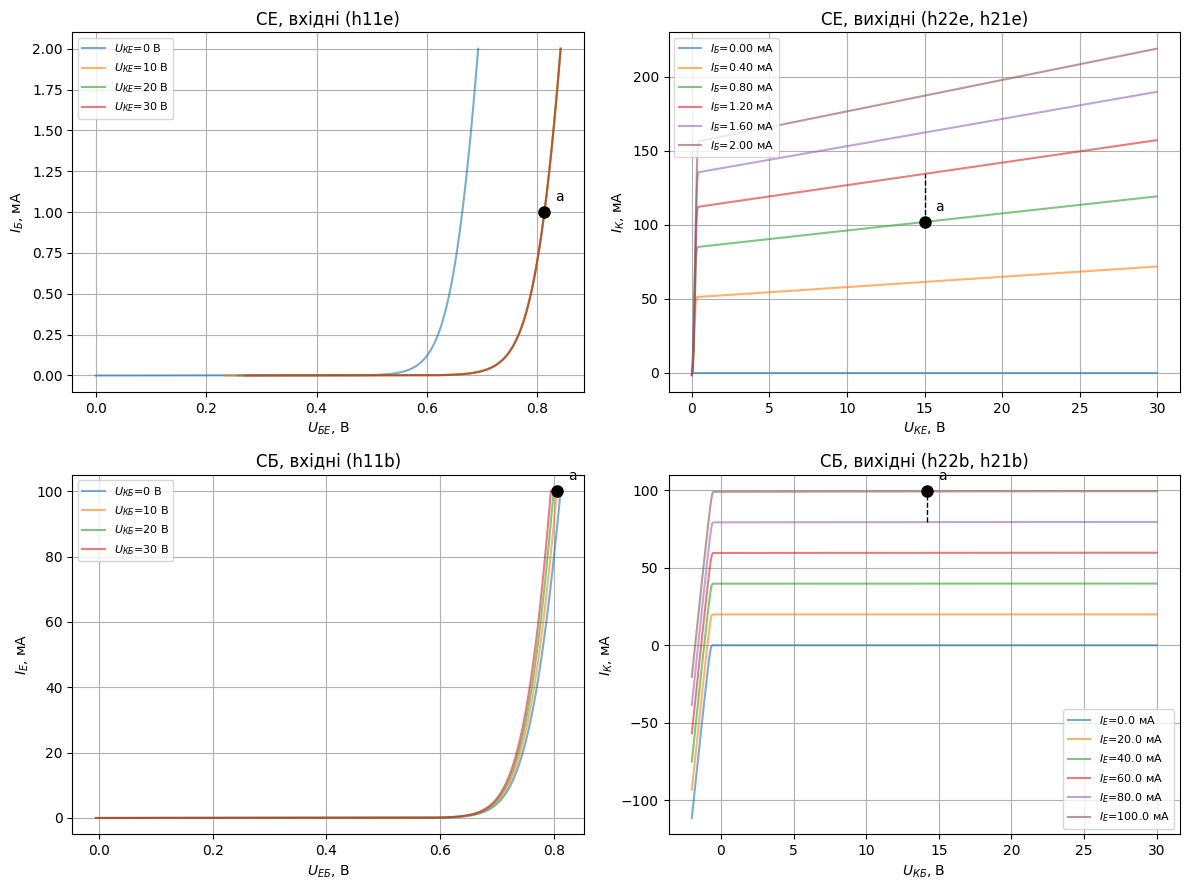

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

ax = axes[0, 0]
for vce, (ib, vbe) in ce_in.items():
    ax.plot(vbe, ib * 1e3, alpha=0.6, label=f'$U_{{КЕ}}$={vce} В')
ax.plot(vbe_a, ib_a * 1e3, 'ko', ms=8)
ax.annotate('a', (vbe_a, ib_a * 1e3), textcoords="offset points", xytext=(8, 8))
ax.set_xlabel('$U_{БЕ}$, В'); ax.set_ylabel('$I_Б$, мА')
ax.set_title('СЕ, вхідні (h11e)'); ax.legend(fontsize=8); ax.grid(True)

ax = axes[0, 1]
for ib, (vce, ic) in ce_out.items():
    ax.plot(vce, ic * 1e3, alpha=0.6, label=f'$I_Б$={ib*1e3:.2f} мА')
ax.plot(Vce0, ic_a * 1e3, 'ko', ms=8)
ax.annotate('a', (Vce0, ic_a * 1e3), textcoords="offset points", xytext=(8, 8))
ax.plot([Vce0, Vce0], [ic_lo * 1e3, ic_hi * 1e3], 'k--', lw=1)
ax.set_xlabel('$U_{КЕ}$, В'); ax.set_ylabel('$I_К$, мА')
ax.set_title('СЕ, вихідні (h22e, h21e)'); ax.legend(fontsize=8); ax.grid(True)

ax = axes[1, 0]
for vcb, (ie, veb) in cb_in.items():
    ax.plot(veb, ie * 1e3, alpha=0.6, label=f'$U_{{КБ}}$={vcb} В')
ax.plot(veb_a, ie_a * 1e3, 'ko', ms=8)
ax.annotate('a', (veb_a, ie_a * 1e3), textcoords="offset points", xytext=(8, 8))
ax.set_xlabel('$U_{ЕБ}$, В'); ax.set_ylabel('$I_Е$, мА')
ax.set_title('СБ, вхідні (h11b)'); ax.legend(fontsize=8); ax.grid(True)

ax = axes[1, 1]
for ie, (vcb, ic) in cb_out.items():
    ax.plot(vcb, ic * 1e3, alpha=0.6, label=f'$I_Е$={ie*1e3:.1f} мА')
ax.plot(Vcb0, ic_a_b * 1e3, 'ko', ms=8)
ax.annotate('a', (Vcb0, ic_a_b * 1e3), textcoords="offset points", xytext=(8, 8))
ax.plot([Vcb0, Vcb0], [ic_lo_b * 1e3, ic_hi_b * 1e3], 'k--', lw=1)
ax.set_xlabel('$U_{КБ}$, В'); ax.set_ylabel('$I_К$, мА')
ax.set_title('СБ, вихідні (h22b, h21b)'); ax.legend(fontsize=8); ax.grid(True)

plt.tight_layout()
plt.show()

## Інтерактивний вибір робочої точки (СЕ)

Дозволяє швидко переглянути, як h-параметри залежать від обраної робочої точки — корисно, щоб кожен член бригади (максимум/середнє/мінімум $I_Б$, п. 3.4.1) підставив власну точку без повторного запуску симуляції.

In [15]:
@interact(Ib0_mA=widgets.FloatSlider(min=0.1, max=1.9, step=0.1, value=1.0, description='$I_{Б0}$, мА'),
          Vce0_V=widgets.FloatSlider(min=1, max=29, step=1, value=15, description='$U_{КЕ0}$, В'))
def explore_ce_operating_point(Ib0_mA, Vce0_V):
    ib0, vce0 = Ib0_mA * 1e-3, Vce0_V
    vce_key = min(ce_in.keys(), key=lambda v: abs(v - vce0))
    h11, *_ = local_slope(*ce_in[vce_key], ib0)
    h21, *_ = cross_family_slope(ce_out, ib0, vce0)
    h12, *_ = cross_family_slope(ce_in, vce0, ib0)
    ib_key = min(ce_out.keys(), key=lambda i: abs(i - ib0))
    h22, *_ = local_slope(*ce_out[ib_key], vce0)
    print(f'h11e = {h11:8.2f} Ом')
    print(f'h12e = {h12:8.5f}')
    print(f'h21e = {h21:8.2f}')
    print(f'h22e = {h22 * 1e6:8.3f} мкСм')

interactive(children=(FloatSlider(value=1.0, description='$I_{Б0}$, мА', max=1.9, min=0.1), FloatSlider(value=…

## Порівняння результатів СЕ і СБ

Фізичні параметри ($r_е, r_б, r_к, \mu_{ек}, \alpha, \beta$) — власні характеристики самого приладу і не повинні залежати від того, з якого сімейства ВАХ (СЕ чи СБ) вони отримані. Порівняйте відповідні рядки `table_3_2`: близькі значення $r_е$, $r_к$, $\alpha$, $\beta$ підтверджують коректність вимірювань; $r_б$ і $\mu_{ек}$ найчутливіші до похибки визначення $h_{12}$ (див. фізичну перевірку $r_е$ вище) і можуть відрізнятись сильніше — це не помилка обчислень, а межа точності графоаналітичного методу при малій кількості кривих сімейства.

In [16]:
table_3_2

,"rе, Ом","rб, Ом","rк, Ом",µек,α,β
СЕ розрахункове значення,2.424625e-08,38.011965,71184.683656,0.000534,0.987824,81.130404
СБ розрахункове значення,9.925257e-01,-45.914835,81250.458981,-0.000565,0.989707,96.150726


## Графічна побудова: проекція синусоїдального сигналу на ВАХ (СЕ)

Класичний графоаналітичний метод розрахунку підсилювального каскаду: робоча точка обирається одночасно на вхідній і вихідній ВАХ, після чого миттєві значення вхідного синусоїдального сигналу почергово "проєктуються" через криві - спочатку через вхідну ВАХ ($u_{бе}\to i_б$), потім через вихідну ВАХ разом з лінією навантаження ($i_б\to u_{ке}$).

**Робоча точка тепер обирається фізично коректно** - через параметри реального каскаду:

* $I_{Б0}$ - струм бази спокою (задається колом зміщення);
* $U_{CC}$, $R_к$ - напруга живлення та опір навантаження в колекторному колі, які визначають **лінію навантаження** $I_К=\dfrac{U_{CC}-U_{КЕ}}{R_к}$;
* $U_{КЕ0}$ (та $I_{К0}$) знаходяться автоматично як точка перетину лінії навантаження з вихідною характеристикою для обраного $I_{Б0}$ - це і є справжня робоча точка каскаду.

Оскільки сімейство вихідних ВАХ змодельоване лише для 6 дискретних значень $I_Б$ (п. 3.3.2), для проміжних струмів крива $I_К=f(U_{КЕ})$ отримується лінійною інтерполяцією між двома найближчими кривими сімейства - точний аналог того, як це робиться "на око" при роботі з паперовим графіком.

In [17]:
ib_family_arr = np.array(sorted(ce_out.keys()))
vce_grid_lc = ce_out[ib_family_arr[0]][0]          # спільна сітка Uке для всіх кривих сімейства
ic_stack = np.array([ce_out[ib][1] for ib in ib_family_arr])


def ic_curve_at_ib(ib_value):
    """Iк = f(Uке) для довільного Iб - лінійна інтерполяція між двома сусідніми кривими сімейства."""
    ib_c = np.clip(ib_value, ib_family_arr.min(), ib_family_arr.max())
    idx = int(np.clip(np.searchsorted(ib_family_arr, ib_c), 1, len(ib_family_arr) - 1))
    ib_lo, ib_hi = ib_family_arr[idx - 1], ib_family_arr[idx]
    w = 0.0 if ib_hi == ib_lo else (ib_c - ib_lo) / (ib_hi - ib_lo)
    return (1 - w) * ic_stack[idx - 1] + w * ic_stack[idx]


def load_line_intersection(ib_value, Vcc, Rc):
    """Перетин кривої Iк(Uке) (при заданому Iб) з лінією навантаження Iк=(Vcc-Uке)/Rc."""
    ic_curve = ic_curve_at_ib(ib_value)
    ic_load = (Vcc - vce_grid_lc) / Rc
    diff = ic_curve - ic_load
    sign_change = np.where(np.diff(np.sign(diff)) != 0)[0]
    if len(sign_change) == 0:
        i = 0 if diff[0] > 0 else len(diff) - 1
        return vce_grid_lc[i], ic_curve[i]
    i = sign_change[0]
    x0, x1 = vce_grid_lc[i], vce_grid_lc[i + 1]
    d0, d1 = diff[i], diff[i + 1]
    vce_x = x0 - d0 * (x1 - x0) / (d1 - d0)
    return vce_x, np.interp(vce_x, vce_grid_lc, ic_curve)

In [20]:
@interact(Ib0_mA=widgets.FloatSlider(min=0.01, max=1.8, step=0.05, value=0.6, description='$I_{Б0}$, мА'),
          Vcc_V=widgets.FloatSlider(min=1, max=30, step=1, value=20, description='$U_{CC}$, В'),
          Rc_kOhm=widgets.FloatSlider(min=0.05, max=0.5, step=0.01, value=0.15, description='$R_к$, кОм'),
          Vm_mV=widgets.FloatSlider(min=1, max=100, step=1, value=10, description='$U_m$, мВ'))
def graphical_projection(Ib0_mA, Vcc_V, Rc_kOhm, Vm_mV):
    Ib0, Rc, Vm = Ib0_mA * 1e-3, Rc_kOhm * 1e3, Vm_mV * 1e-3

    # --- робоча точка: перетин Ib0-кривої з лінією навантаження ---
    Vce0, Ic0 = load_line_intersection(Ib0, Vcc_V, Rc)
    vce_key = min(ce_in.keys(), key=lambda v: abs(v - Vce0))
    ib_arr, vbe_arr = ce_in[vce_key]
    Vbe0 = np.interp(Ib0, ib_arr, vbe_arr)

    # --- вхідний синусоїдальний сигнал (по фазі, а не по часу - метод суто графічний) ---
    phase = np.linspace(0, 360, 361)
    vbe_t = Vbe0 + Vm * np.sin(np.radians(phase))

    # --- проекція 1: вхідна ВАХ,  u_бе(t) -> i_б(t) ---
    order = np.argsort(vbe_arr)
    ib_t = np.interp(vbe_t, vbe_arr[order], ib_arr[order])
    clipped = (ib_t.min() < ib_family_arr.min()) or (ib_t.max() > ib_family_arr.max())
    ib_t = np.clip(ib_t, ib_family_arr.min(), ib_family_arr.max())

    # --- проекція 2: вихідна ВАХ + лінія навантаження,  i_б(t) -> u_ке(t) ---
    vce_t = np.array([load_line_intersection(ib, Vcc_V, Rc)[0] for ib in ib_t])
    ic_t = (Vcc_V - vce_t) / Rc

    # ------------------------------ графіки ------------------------------
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))

    ax = axes[0, 0]
    for vce, (ib_a, vbe_a) in ce_in.items():
        ax.plot(vbe_a, ib_a * 1e3, alpha=0.35)
    ax.plot(vbe_t, ib_t * 1e3, 'r-', lw=2)
    ax.plot(Vbe0, Ib0 * 1e3, 'ko', ms=7)
    ax.annotate('Q', (Vbe0, Ib0 * 1e3), textcoords="offset points", xytext=(6, 6))
    ax.set_xlabel('$u_{бе}$, В'); ax.set_ylabel('$i_б$, мА')
    ax.set_title('Вхідна ВАХ: $u_{бе}(t)\\to i_б(t)$')
    ax.grid(True)

    ax = axes[0, 1]
    ax.plot(phase, ib_t * 1e3, 'r-')
    ax.axhline(Ib0 * 1e3, color='gray', ls=':')
    ax.set_xlabel('$\\omega t$, град'); ax.set_ylabel('$i_б$, мА')
    ax.set_title('Струм бази $i_б(t)$' + ('  (ОБМЕЖЕННЯ!)' if clipped else ''))
    ax.grid(True)

    ax = axes[1, 0]
    for ib, (vce_a, ic_a) in ce_out.items():
        ax.plot(vce_a, ic_a * 1e3, alpha=0.35)
    ax.plot(vce_grid_lc, np.clip((Vcc_V - vce_grid_lc) / Rc * 1e3, 0, None), 'k--', lw=1.3, label='лінія навантаження')
    ax.plot(vce_t, ic_t * 1e3, 'r-', lw=2)
    ax.plot(Vce0, Ic0 * 1e3, 'ko', ms=7)
    ax.annotate('Q', (Vce0, Ic0 * 1e3), textcoords="offset points", xytext=(6, 6))
    ax.set_xlim(0, Vcc_V * 1.05)
    ax.set_ylim(0, max(Vcc_V / Rc * 1e3, ic_t.max() * 1e3) * 1.1)
    ax.set_xlabel('$u_{ке}$, В'); ax.set_ylabel('$i_к$, мА')
    ax.set_title('Вихідна ВАХ + лінія навантаження: $i_б(t)\\to u_{ке}(t)$')
    ax.legend(fontsize=8); ax.grid(True)

    ax = axes[1, 1]
    ax.plot(phase, vce_t, 'b-', lw=2)
    ax.axhline(Vce0, color='gray', ls=':')
    ax.set_xlabel('$\\omega t$, град'); ax.set_ylabel('$u_{ке}$, В')
    ax.set_title('Вихідна напруга $u_{ке}(t)$')
    ax.grid(True)

    plt.tight_layout()
    plt.show()

    Vout_amp = (vce_t.max() - vce_t.min()) / 2
    Ku = Vout_amp / Vm if Vm > 0 else float('nan')
    print(f'Робоча точка:  Ib0={Ib0*1e3:.2f} мА   Vbe0={Vbe0:.3f} В   Vce0={Vce0:.2f} В   Ic0={Ic0*1e3:.2f} мА')
    print(f'Вихідний сигнал:  амплітуда u_ке = {Vout_amp:.2f} В,  розмах = {2*Vout_amp:.2f} В,  Ku = Uвих/Uвх ~= {Ku:.1f}')
    if clipped:
        print('Увага: i_б(t) виходить за межі змодельованого діапазону (0..2 мА) - на графіках видно обмеження (нелінійне спотворення).')

interactive(children=(FloatSlider(value=0.6, description='$I_{Б0}$, мА', max=1.8, min=0.01, step=0.05), FloatS…

## Висновки

*(заповнюється студентом)*

1. Порівняти отримані h-параметри та фізичні параметри транзистора для схем СЕ і СБ (таблиці 3.1, 3.2) — чи узгоджуються розрахункові значення між собою.
2. Порівняти розрахункові значення з довідниковими (якщо вони були внесені).
3. Пояснити спостережуваний нахил вихідних характеристик (ефект Ерлі, $h_{22е}\neq0$) та відхилення $\beta=I_К/I_Б$ від сталого значення при великих струмах (вплив параметра `Ikf` моделі — високий рівень інжекції).
4. Зазначити, які параметри моделі 2N3904 (Bf, Rb, Vaf, Ikf, ...) визначають вигляд отриманих характеристик, і що зміниться при підстановці точної моделі транзистора власної бригади.
5. За графічною побудовою (розділ "Графічна побудова...") пояснити: чому вихідний сигнал інвертований відносно вхідного; чому форма $i_б(t)$ несиметрична навіть при симетричній синусоїді $u_{бе}(t)$ (нелінійність вхідної ВАХ); за яких умов ($U_m$, положення робочої точки на лінії навантаження) з'являється обмеження (відсікання) вихідного сигналу.

## Рекомендована література

1. Алехин В. А. Электротехника и электроника. Компьютерный лабораторный практикум в программной среде TINA-8. — Москва: Горячая линия — Телеком, 2014. — 208 с.
2. Руденко В.С., Сенько В.И., Трифонюк В.В. Основы промышленной электроники. — Киев: Вища школа, 1985. — 400 с.
3. Степаненко И.П. Основы теории транзисторов и транзисторных схем. — Москва: Энергия, 1977.
4. Пасынков В.В., Чиркин Л.К. Полупроводниковые приборы. — Москва: Высшая школа, 1987.
5. Дулин В.Н. и др. Электронные приборы / под ред. Г.Г. Шишкина. — Москва: Энергоатомиздат, 1989.